<a href="https://colab.research.google.com/github/sayim665/atml-pa0/blob/main/task4_vae/task4_vae.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 4 — VAE Task

ATML PA0 — Task 4

Sections:
1. Building a Basic VAE in PyTorch (MNIST)
2. Analyzing VAE Performance (latent space, reconstructions, generation)
3. Comparing with Doersch's VAE Implementation (written discussion)

## Setup

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(0)
os.makedirs("results", exist_ok=True)
os.makedirs("../figures", exist_ok=True)

Using device: cuda


## Data — MNIST

In [2]:
transform = transforms.Compose([transforms.ToTensor()])  # pixels in [0,1], matches Bernoulli assumption

train_set = datasets.MNIST(root="../data", train=True, download=True, transform=transform)
test_set = datasets.MNIST(root="../data", train=False, download=True, transform=transform)

BATCH_SIZE = 128
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(len(train_set), "train,", len(test_set), "test images")

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.04MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.9MB/s]

60000 train, 10000 test images


## 1. Building a Basic VAE

Latent dim = 2 for easy visualization (Section 2a explicitly asks for this).

In [3]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=2):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder: x -> hidden -> (mu, logvar)
        self.enc_fc1 = nn.Linear(input_dim, hidden_dim)
        self.enc_mu = nn.Linear(hidden_dim, latent_dim)
        self.enc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder: z -> hidden -> logits over pixels
        self.dec_fc1 = nn.Linear(latent_dim, hidden_dim)
        self.dec_out = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h = F.relu(self.enc_fc1(x))
        mu = self.enc_mu(h)
        logvar = self.enc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.dec_fc1(z))
        logits = self.dec_out(h)  # raw logits; apply sigmoid outside for probabilities
        return logits

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        logits = self.decode(z)
        return logits, mu, logvar


def vae_loss(logits, x, mu, logvar):
    # Reconstruction: binary cross-entropy (Bernoulli likelihood), summed over pixels
    recon_loss = F.binary_cross_entropy_with_logits(logits, x, reduction="sum")
    # KL divergence between q(z|x) = N(mu, sigma^2) and prior N(0, I), closed form
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss, recon_loss, kl_loss


LATENT_DIM = 2
model = VAE(input_dim=784, hidden_dim=400, latent_dim=LATENT_DIM).to(device)
print(model)

VAE(
  (enc_fc1): Linear(in_features=784, out_features=400, bias=True)
  (enc_mu): Linear(in_features=400, out_features=2, bias=True)
  (enc_logvar): Linear(in_features=400, out_features=2, bias=True)
  (dec_fc1): Linear(in_features=2, out_features=400, bias=True)
  (dec_out): Linear(in_features=400, out_features=784, bias=True)
)


In [4]:
def train_vae(model, loader, test_loader, epochs=15, lr=1e-3, checkpoint_path=None):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "train_recon": [], "train_kl": [], "test_loss": []}

    for epoch in range(epochs):
        model.train()
        total_loss, total_recon, total_kl, n = 0.0, 0.0, 0.0, 0
        for x, _ in tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}"):
            x = x.view(x.size(0), -1).to(device)  # flatten 28x28 -> 784
            optimizer.zero_grad()
            logits, mu, logvar = model(x)
            loss, recon, kl = vae_loss(logits, x, mu, logvar)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_recon += recon.item()
            total_kl += kl.item()
            n += x.size(0)

        avg_loss = total_loss / n
        avg_recon = total_recon / n
        avg_kl = total_kl / n

        # quick test-set loss check
        model.eval()
        test_loss, test_n = 0.0, 0
        with torch.no_grad():
            for x, _ in test_loader:
                x = x.view(x.size(0), -1).to(device)
                logits, mu, logvar = model(x)
                loss, _, _ = vae_loss(logits, x, mu, logvar)
                test_loss += loss.item()
                test_n += x.size(0)
        avg_test_loss = test_loss / test_n

        history["train_loss"].append(avg_loss)
        history["train_recon"].append(avg_recon)
        history["train_kl"].append(avg_kl)
        history["test_loss"].append(avg_test_loss)
        print(f"Epoch {epoch+1}: train_loss={avg_loss:.2f} (recon={avg_recon:.2f}, kl={avg_kl:.2f}) test_loss={avg_test_loss:.2f}")

        if checkpoint_path is not None:
            os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)
            torch.save({"model_state": model.state_dict(), "history": history, "epoch": epoch+1}, checkpoint_path)

    return history


history = train_vae(model, train_loader, test_loader, epochs=15, lr=1e-3,
                     checkpoint_path="results/vae_latent2_checkpoint.pt")

Epoch 1/15:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1: train_loss=187.62 (recon=181.81, kl=5.81) test_loss=169.12


Epoch 2/15:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2: train_loss=166.48 (recon=161.26, kl=5.21) test_loss=164.07


Epoch 3/15:   0%|          | 0/469 [00:00<?, ?it/s]

...

Epoch 13: train_loss=151.97 (recon=146.09, kl=5.87) test_loss=152.89


Epoch 14/15:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 14: train_loss=151.59 (recon=145.67, kl=5.91) test_loss=152.63


Epoch 15/15:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 15: train_loss=151.22 (recon=145.28, kl=5.94) test_loss=152.06


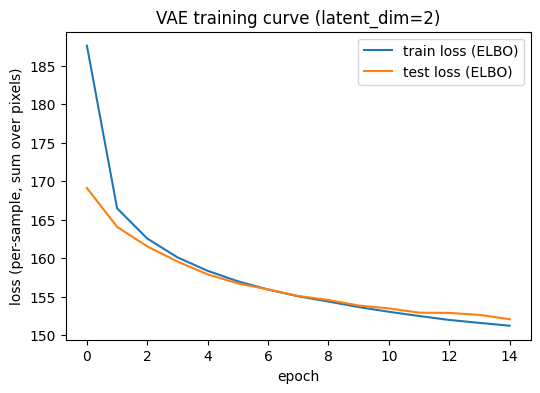

In [5]:
plt.figure(figsize=(6,4))
plt.plot(history["train_loss"], label="train loss (ELBO)")
plt.plot(history["test_loss"], label="test loss (ELBO)")
plt.xlabel("epoch"); plt.ylabel("loss (per-sample, sum over pixels)")
plt.legend(); plt.title("VAE training curve (latent_dim=2)")
plt.savefig("../figures/task4_training_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Analyzing VAE Performance

### 2a. Latent Space Visualization

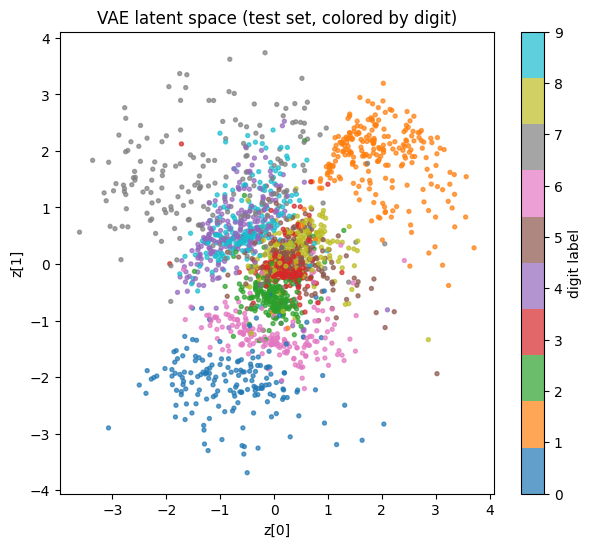

In [6]:
@torch.no_grad()
def get_latent_means(model, loader, n_samples=2000):
    model.eval()
    mus, labels = [], []
    count = 0
    for x, y in loader:
        x = x.view(x.size(0), -1).to(device)
        mu, _ = model.encode(x)
        mus.append(mu.cpu().numpy())
        labels.append(y.numpy())
        count += x.size(0)
        if count >= n_samples:
            break
    return np.concatenate(mus)[:n_samples], np.concatenate(labels)[:n_samples]

latent_mus, latent_labels = get_latent_means(model, test_loader, n_samples=2000)

plt.figure(figsize=(7,6))
scatter = plt.scatter(latent_mus[:,0], latent_mus[:,1], c=latent_labels, cmap="tab10", s=8, alpha=0.7)
plt.colorbar(scatter, label="digit label")
plt.xlabel("z[0]"); plt.ylabel("z[1]")
plt.title("VAE latent space (test set, colored by digit)")
plt.savefig("../figures/task4_latent_space.png", dpi=150, bbox_inches="tight")
plt.show()

**Discussion:** Do clusters for each digit make sense? Is there a continuous progression between digits?

> TODO: your answer here.

### 2b. Reconstruction Quality

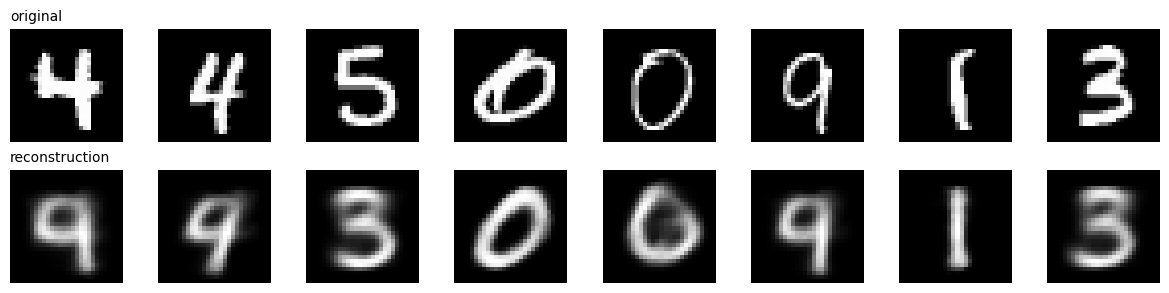

In [7]:
@torch.no_grad()
def show_reconstructions(model, dataset, n=8):
    model.eval()
    idx = np.random.default_rng(0).choice(len(dataset), size=n, replace=False)
    originals, recons = [], []
    for i in idx:
        x, _ = dataset[i]
        x_flat = x.view(1, -1).to(device)
        logits, mu, logvar = model(x_flat)
        recon = torch.sigmoid(logits).view(28, 28).cpu().numpy()
        originals.append(x.view(28, 28).numpy())
        recons.append(recon)

    fig, axes = plt.subplots(2, n, figsize=(1.5*n, 3))
    for i in range(n):
        axes[0, i].imshow(originals[i], cmap="gray"); axes[0, i].axis("off")
        axes[1, i].imshow(recons[i], cmap="gray"); axes[1, i].axis("off")
    axes[0, 0].set_title("original", loc="left", fontsize=10)
    axes[1, 0].set_title("reconstruction", loc="left", fontsize=10)
    plt.tight_layout()
    plt.savefig("../figures/task4_reconstructions.png", dpi=150, bbox_inches="tight")
    plt.show()

show_reconstructions(model, test_set, n=8)

**Discussion:** Are important features preserved? Any blurriness/distortion? Particular digits reconstructed better/worse?

> TODO: your answer here.

### 2c. Generation of New Samples

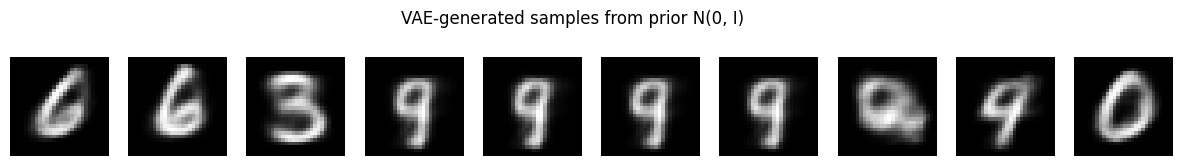

In [8]:
@torch.no_grad()
def generate_samples(model, n=10, latent_dim=2):
    model.eval()
    z = torch.randn(n, latent_dim).to(device)  # sample from prior N(0, I)
    logits = model.decode(z)
    samples = torch.sigmoid(logits).view(n, 28, 28).cpu().numpy()
    return samples

samples = generate_samples(model, n=10, latent_dim=LATENT_DIM)

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, ax in enumerate(axes):
    ax.imshow(samples[i], cmap="gray")
    ax.axis("off")
plt.suptitle("VAE-generated samples from prior N(0, I)")
plt.savefig("../figures/task4_generated_samples.png", dpi=150, bbox_inches="tight")
plt.show()

**Discussion:** Do samples look like valid handwritten digits? Do they reflect dataset diversity?

> TODO: your answer here.

### Optional: higher latent dimension for comparison

Train a second VAE with a larger latent dim (e.g. 10 or 20) to see if reconstruction/generation quality improves -- useful for the Doersch comparison discussion below (he notes VAEs are "insensitive to dimensionality of z" over a broad range).

In [9]:
LATENT_DIM_HIGH = 10
model_high = VAE(input_dim=784, hidden_dim=400, latent_dim=LATENT_DIM_HIGH).to(device)

history_high = train_vae(model_high, train_loader, test_loader, epochs=15, lr=1e-3,
                          checkpoint_path="results/vae_latent10_checkpoint.pt")

Epoch 1/15:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1: train_loss=162.81 (recon=149.23, kl=13.58) test_loss=128.66


Epoch 2/15:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2: train_loss=125.07 (recon=108.48, kl=16.59) test_loss=120.72


Epoch 3/15:   0%|          | 0/469 [00:00<?, ?it/s]

...

Epoch 13: train_loss=109.81 (recon=91.45, kl=18.36) test_loss=109.20


Epoch 14/15:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 14: train_loss=109.45 (recon=91.02, kl=18.43) test_loss=108.79


Epoch 15/15:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 15: train_loss=109.10 (recon=90.60, kl=18.50) test_loss=108.52


Latent dim 2  -- final test loss: 152.06
Latent dim 10 -- final test loss: 108.52


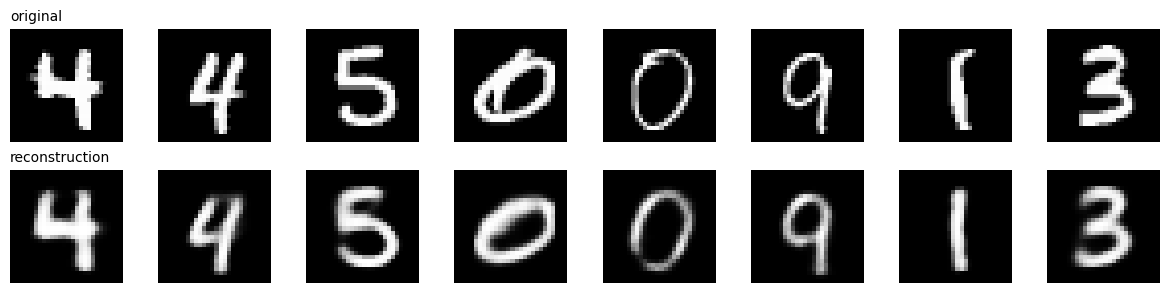

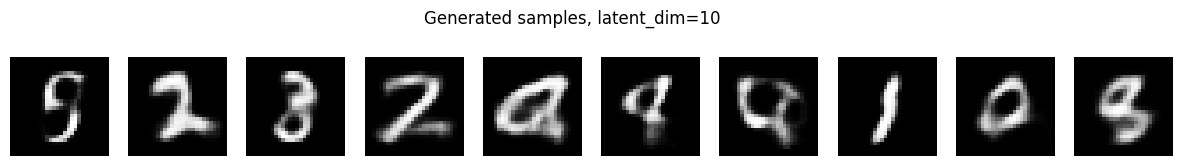

In [10]:
# Compare reconstruction quality and final loss between latent_dim=2 and latent_dim=10
print(f"Latent dim 2  -- final test loss: {history['test_loss'][-1]:.2f}")
print(f"Latent dim 10 -- final test loss: {history_high['test_loss'][-1]:.2f}")

show_reconstructions(model_high, test_set, n=8)

samples_high = generate_samples(model_high, n=10, latent_dim=LATENT_DIM_HIGH)
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, ax in enumerate(axes):
    ax.imshow(samples_high[i], cmap="gray")
    ax.axis("off")
plt.suptitle("Generated samples, latent_dim=10")
plt.savefig("../figures/task4_generated_samples_latent10.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Comparing with Doersch's VAE Implementation

**Discussion prompts (answer after reading the relevant section of Doersch's tutorial, arXiv:1606.05908):**
- Architecture: MLP vs. what Doersch used, hidden units/layers comparison.
- Output distribution and loss: does Doersch's Bernoulli/sigmoid-cross-entropy choice match ours?
- Latent dimensionality: what did you choose, did you experiment with different sizes (see optional cell above), any difference observed?
- Results comparison: qualitative similarity/difference in generated samples, any "failure cases" (digits that look like a mix of two classes)?

> TODO: your answer here.